<a href="https://colab.research.google.com/github/sajed-zarrinpour/science/blob/main/On%20enhancing%20neural-numerical%20methods/setting2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

On enhancing numerical methods with neural networks

Loading the data

In [5]:
import pandas as pd

# data file which resides in github repo
file = "https://raw.githubusercontent.com/sajed-zarrinpour/science/main/On%20enhancing%20neural-numerical%20methods/laplace.csv"
# makes the passed rows header
data = pd.read_csv(file, header =[0])

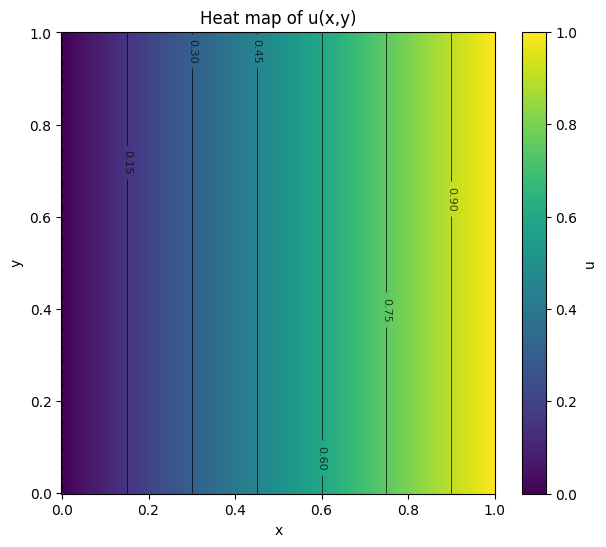

In [9]:
# lets see what are we workng on

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

df = data
# Ensure columns
df = df.rename(columns={df.columns[0]:'x', df.columns[1]:'y', df.columns[2]:'u'})  # safe rename if unnamed
x = df['x'].values
y = df['y'].values
u = df['u'].values

# Create grid (adjust resolution)
nx, ny = 300, 300
xi = np.linspace(x.min(), x.max(), nx)
yi = np.linspace(y.min(), y.max(), ny)
X, Y = np.meshgrid(xi, yi)

# Interpolate scattered u onto grid
Ui = griddata((x, y), u, (X, Y), method='cubic')   # try 'linear' or 'nearest' if NaNs

# Optionally fill remaining NaNs using nearest
if np.isnan(Ui).any():
    Ui_nearest = griddata((x, y), u, (X, Y), method='nearest')
    Ui = np.where(np.isnan(Ui), Ui_nearest, Ui)

# Plot heatmap + contours
fig, ax = plt.subplots(figsize=(7,6))
pcm = ax.pcolormesh(X, Y, Ui, shading='auto', cmap='viridis')
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label('u')

# Contours
CS = ax.contour(X, Y, Ui, levels=8, colors='k', linewidths=0.7, alpha=0.7)
ax.clabel(CS, inline=True, fontsize=8)

# ax.scatter(x, y, c='white', s=10, edgecolors='k', linewidth=0.03)  # shows sample points
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Heat map of u(x,y)')
plt.show()


In [ ]:
data

,x,y,u
0,0.00,0.0,0.00
1,0.01,0.0,0.01
2,0.02,0.0,0.02
3,0.03,0.0,0.03
4,0.04,0.0,0.04
...,...,...,...
10196,0.96,1.0,0.96
10197,0.97,1.0,0.97
10198,0.98,1.0,0.98
10199,0.99,1.0,0.99


In [10]:
import numpy as np
converted = np.array(data)

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(converted[:,0:2], converted[:,2], test_size=0.33, random_state=42)

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import os
# Keras :
from keras import backend as K
import tensorflow as tf
import keras
from keras.layers import Input, Dense, add, Activation, Reshape , Conv1D, Flatten ,GlobalAveragePooling1D , Lambda, Dropout, concatenate
from keras.models import Model, model_from_json
from keras import optimizers
from keras.callbacks import CSVLogger
from keras.losses import MeanSquaredError as mse

In [16]:

# optimizer (NAdam) parameters
lr = 0.05       # learning rate
beta_1=0.9       # beta 1
beta_2=0.999     # beta 2

In [24]:
class EarlyStoppingAtMinLoss(tf.keras.callbacks.Callback):
  """Stop training when the loss is at its min, i.e. the loss stops decreasing.

  Arguments:
      patience: Number of epochs to wait after min has been hit. After this
      number of no improvement, training stops.
  """

  def __init__(self, patience=20):
    super(EarlyStoppingAtMinLoss, self).__init__()

    self.patience = patience

    # best_weights to store the weights at which the minimum loss occurs.
    self.best_weights = None

  def on_train_begin(self, logs=None):
    # The number of epoch it has waited when loss is no longer minimum.
    self.wait = 0
    # The epoch the training stops at.
    self.stopped_epoch = 0
    # Initialize the best as infinity.
    self.best = np.inf

  def on_epoch_end(self, epoch, logs=None):
    current = logs.get('loss')
    if np.less(current, self.best):
      self.best = current
      self.wait = 0
      # Record the best weights if current results is better (less).
      self.best_weights = self.model.get_weights()
    else:
      self.wait += 1
      if self.wait >= self.patience:
        self.stopped_epoch = epoch
        self.model.stop_training = True
        print('Restoring model weights from the end of the best epoch.')
        self.model.set_weights(self.best_weights)

  def on_train_end(self, logs=None):
    if self.stopped_epoch > 0:
      print('Epoch %05d: early stopping' % (self.stopped_epoch + 1))

In [40]:
# enabling eager execution
tf.config.run_functions_eagerly(True)
tf.data.experimental.enable_debug_mode()


x = tf.keras.Input(shape=(1, ))
y = tf.keras.Input(shape=(1,))
merged = keras.layers.Concatenate(axis=1)([x, y])
dense1 = keras.layers.Dense(10, input_dim=2, activation=keras.activations.sigmoid, use_bias=True)(merged)
u = keras.layers.Dense(1, activation=keras.activations.relu, use_bias=True)(dense1)
model = keras.models.Model(inputs=[x, y], outputs=u)



model.compile(optimizer=optimizers.Nadam(learning_rate=0.05, beta_1=0.9, beta_2=0.999),
            loss='mse',
            metrics=['mae']
            )
history = model.fit([X_train[:,0], X_train[:,1]], y_train,validation_split=0.15, epochs=150, batch_size=50, callbacks=[EarlyStoppingAtMinLoss(15)])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/150
117/117 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - loss: 0.3446 - mae: 0.5112 - val_loss: 0.3255 - val_mae: 0.4905
Epoch 2/150
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 0.3342 - mae: 0.4994 - val_loss: 0.3255 - val_mae: 0.4905
Epoch 3/150
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - loss: 0.3372 - mae: 0.5020 - val_loss: 0.3255 - val_mae: 0.4905
Epoch 4/150
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 0.3410 - mae: 0.5055 - val_loss: 0.3255 - val_mae: 0.4905
Epoch 5/150
117/117 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - loss: 0.3345 - mae: 0.5001 - val_loss: 0.3255 - val_mae: 0.4905
Epoch 6/150
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 0.3333 - mae: 0.5003 - val_loss: 0.3255 - val_mae: 0.4905
Epoch 7/150
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - loss: 0.3384 - mae: 0.5040 - val_loss: 0.3255 - val_mae: 0.4905
Epoch 8/150
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - loss: 0.3446 - mae: 0.5097 - val_loss: 0.3255 - val_mae: 0.4905
Epoch 9/150
117/117 ━━━━━━━━━━━━━━━━━━━━

In [43]:
# history = model.fit([X_train[:,0], X_train[:,1]], [np.repeat(y_train[:, np.newaxis], 2, axis=1), y_train],validation_split=0.15, epochs=300, batch_size=70, callbacks=[EarlyStoppingAtMinLoss(15)])
model.evaluate([X_test[:,0],X_test[:,0]], y_test)

106/106 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.3333 - mae: 0.4980


[0.330499529838562, 0.49532511830329895]

In [ ]:
def grad2(I):
    with tf.GradientTape() as t:
        t.watch(I[0])
        t.watch(I[1])
        z = model(I)
    grad = t.gradient(z, {'x': I[0], 'y': I[1]})
    return -1*(grad['x']+grad['y'])

In [44]:
x = tf.keras.Input(shape=(1, ))
y = tf.keras.Input(shape=(1,))
ml = model([x,y])
g = Lambda(grad2, name="grad2")((x,y))
d = keras.layers.Dense(2, input_dim=2, activation=keras.activations.sigmoid, use_bias=True)(ml)
model2 = keras.models.Model(inputs=[x, y], outputs=[d,g])


model2.compile(optimizer=optimizers.Nadam(learning_rate=0.05, beta_1=0.9, beta_2=0.999),
             loss=['mse','mse'],
             loss_weights=[0.5,0.5],
             metrics=['mae', 'mae']
             )
# fitting the data with model (learning process)
history2 = model2.fit(
    [
        X_train[:,0],
        X_train[:,1]
    ],
    [
        np.repeat(y_train[:, np.newaxis], 2, axis=1),
        y_train
    ],
    validation_split=0.15,
    epochs=300,
    batch_size=70,
    callbacks=[EarlyStoppingAtMinLoss(15)]
)

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


83/83 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - dense_12_loss: 0.0844 - dense_12_mae: 0.2511 - grad2_loss: 0.3374 - grad2_mae: 0.5032 - loss: 0.2109 - val_dense_12_loss: 0.0850 - val_dense_12_mae: 0.2541 - val_grad2_loss: 0.3255 - val_grad2_mae: 0.4905 - val_loss: 0.2052
Epoch 2/300
83/83 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - dense_12_loss: 0.0846 - dense_12_mae: 0.2512 - grad2_loss: 0.3372 - grad2_mae: 0.5029 - loss: 0.2109 - val_dense_12_loss: 0.0855 - val_dense_12_mae: 0.2547 - val_grad2_loss: 0.3255 - val_grad2_mae: 0.4905 - val_loss: 0.2055
Epoch 3/300
83/83 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - dense_12_loss: 0.0863 - dense_12_mae: 0.2548 - grad2_loss: 0.3379 - grad2_mae: 0.5018 - loss: 0.2121 - val_dense_12_loss: 0.0850 - val_dense_12_mae: 0.2542 - val_grad2_loss: 0.3255 - val_grad2_mae: 0.4905 - val_loss: 0.2053
Epoch 4/300
83/83 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - dense_12_loss: 0.0840 - dense_12_mae: 0.2511 - grad2_loss: 0.3417 - grad2_mae: 0.5079 - loss: 0.2128 - val_dense_12_loss

In [47]:
model2.evaluate([X_test[:,0],X_test[:,0]], [np.repeat(y_test[:, np.newaxis], 2, axis=1), y_test])

106/106 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - dense_12_loss: 0.0854 - dense_12_mae: 0.2522 - grad2_loss: 0.3333 - grad2_mae: 0.4980 - loss: 0.2094


[0.20784957706928253,
 0.08519941568374634,
 0.330499529838562,
 0.25175848603248596,
 0.49532511830329895]

In [48]:
predicted_u = model2.predict([X_test[:,0],X_test[:,0]],batch_size=150)


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [50]:
predicted_u

[array([[0.48847914, 0.48847914],
        [0.48847914, 0.48847914],
        [0.48847914, 0.48847914],
        ...,
        [0.48847914, 0.48847914],
        [0.48847914, 0.48847914],
        [0.48847914, 0.48847914]], dtype=float32),
 array([[-0.],
        [-0.],
        [-0.],
        ...,
        [-0.],
        [-0.],
        [-0.]], dtype=float32)]

In [51]:
print('mean of prediction : %.8f' % (np.mean(predicted_u[0])))
print('norm of the mean of the commited error : %.8f' % (np.linalg.norm(np.mean(predicted_u[0]) - np.mean(y_test))))


mean of prediction : 0.48847914
norm of the mean of the commited error : 0.00684608


$||∑_{i=0}^{len(u_{predicted}[0])}u_{predicted}[0][i]-y_{test}[i]||\$

In [52]:
err =[]
for i in range(len(predicted_u[0])):
    err.append(predicted_u[0][i]-y_test[i])
err = np.array(err)
print('mean of L2 commited error: %.8f'%(np.linalg.norm(err)))

mean of L2 commited error: 23.95272118


$∑_{i=0}^{len(u_{predicted}[0])}||u_{predicted}[0][i]-y_{test}[i]||_{L^2}$

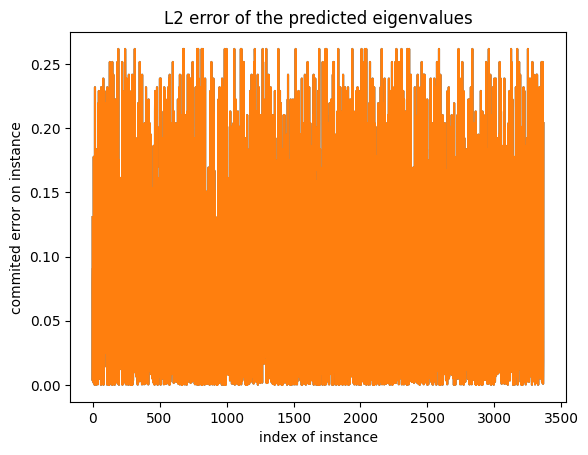

Percentage of the commited error between 0,5e-6 is: 1.06920107
Percentage of the commited error between 5e-6,5e-5 is: 0.00000000
Percentage of the commited error between 5e-5,5e-4 is: 3.89070389
Percentage of the commited error between 5e-4,5e-3 is: 9.26640927
Percentage of the commited error between 5e-3,5e-2 is: 31.39293139
Percentage of the commited error between 5e-2,5e-1 is: 54.38075438


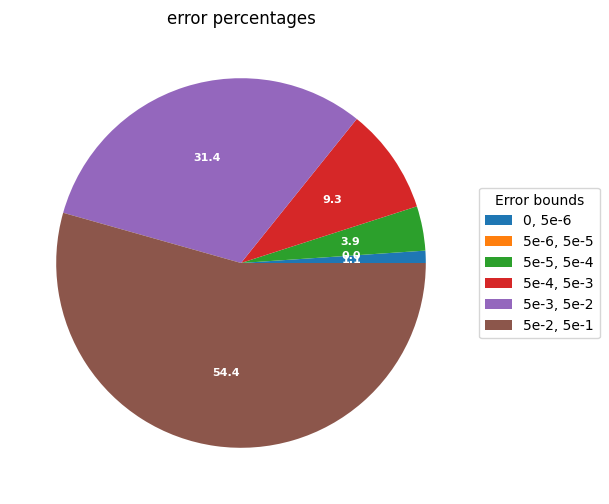

In [53]:
L2_Errors = []
for i in range(len(predicted_u[0])):
    L2_Errors.append((y_test[i] - predicted_u[0][i])**2)

import matplotlib.pyplot as plt
plt.plot(L2_Errors)
plt.title('L2 error of the predicted eigenvalues')
plt.ylabel('commited error on instance')
plt.xlabel('index of instance')
plt.show()

T1 = 0
T2 = 5e-6
T3 = 5e-5
T4 = 5e-4
T5 = 5e-3
T6 = 5e-2
T7 = 5e-1
S1=S2=S3=S4=S5=S6=0.0
for item in L2_Errors:
    if (item[0]>=T1 and item[0]< T2):
        S1 = S1 + 1
    elif (item[0]>=T2 and item[0]< T3):
        S2 = S2 + 1
    elif (item[0]>=T3 and item[0]< T4):
        S3 = S3 + 1
    elif (item[0]>=T4 and item[0]< T5):
        S4 = S4 + 1
    elif (item[0]>=T5 and item[0]< T6):
        S5 = S5 + 1
    elif (item[0]>=T6 and item[0]< T7):
        S6 = S6 + 1
print('Percentage of the commited error between 0,5e-6 is: %.8f' % ((S1/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-6,5e-5 is: %.8f' % ((S2/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-5,5e-4 is: %.8f' % ((S3/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-4,5e-3 is: %.8f' % ((S4/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-3,5e-2 is: %.8f' % ((S5/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-2,5e-1 is: %.8f' % ((S6/len(L2_Errors)) * 100))

fig, ax = plt.subplots(figsize=(12, 6), subplot_kw=dict(aspect="equal"))


data_to_plot = [(S1/len(L2_Errors)),
          (S2/len(L2_Errors)),
          (S3/len(L2_Errors)),
          (S4/len(L2_Errors)),
          (S5/len(L2_Errors)),
          (S6/len(L2_Errors))]
ingredients = ["0, 5e-6",
               "5e-6, 5e-5",
               "5e-5, 5e-4",
               "5e-4, 5e-3",
               "5e-3, 5e-2",
               "5e-2, 5e-1",]


def func(pct, allvals):
    return "{:.1f}".format(pct)


wedges, texts, autotexts = ax.pie(data_to_plot, autopct=lambda pct: func(pct, data_to_plot),
                                  textprops=dict(color="w"))

ax.legend(wedges, ingredients,
          title="Error bounds",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.setp(autotexts, size=8, weight="bold")

ax.set_title("error percentages")

plt.show()

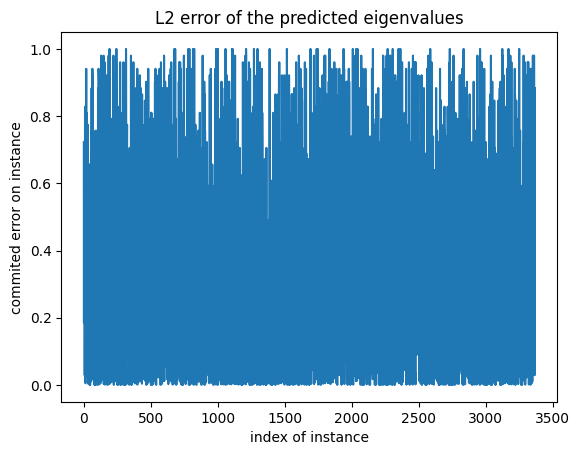

Percentage of the commited error between 0,5e-6 is: 0.83160083
Percentage of the commited error between 5e-6,5e-5 is: 0.00000000
Percentage of the commited error between 5e-5,5e-4 is: 1.98990199
Percentage of the commited error between 5e-4,5e-3 is: 6.08850609
Percentage of the commited error between 5e-3,5e-2 is: 13.98871399
Percentage of the commited error between 5e-2,5e-1 is: 48.52984853


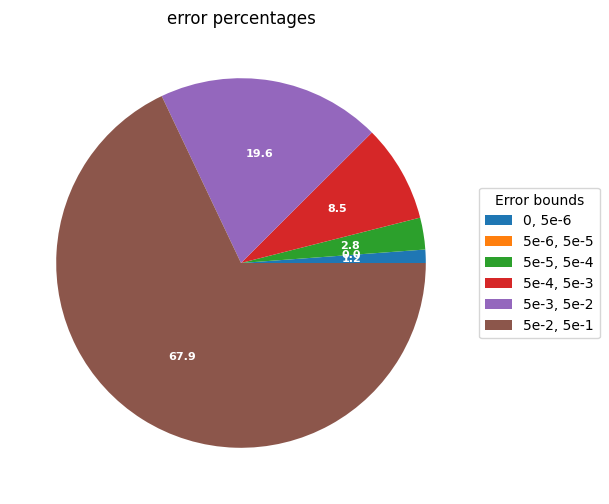

In [54]:
L2_Errors = []
for i in range(len(predicted_u[1])):
    L2_Errors.append((y_test[i] - predicted_u[1][i])**2)

import matplotlib.pyplot as plt
plt.plot(L2_Errors)
plt.title('L2 error of the predicted eigenvalues')
plt.ylabel('commited error on instance')
plt.xlabel('index of instance')
plt.show()

T1 = 0
T2 = 5e-6
T3 = 5e-5
T4 = 5e-4
T5 = 5e-3
T6 = 5e-2
T7 = 5e-1
S1=S2=S3=S4=S5=S6=0.0
for item in L2_Errors:
    if (item[0]>=T1 and item[0]< T2):
        S1 = S1 + 1
    elif (item[0]>=T2 and item[0]< T3):
        S2 = S2 + 1
    elif (item[0]>=T3 and item[0]< T4):
        S3 = S3 + 1
    elif (item[0]>=T4 and item[0]< T5):
        S4 = S4 + 1
    elif (item[0]>=T5 and item[0]< T6):
        S5 = S5 + 1
    elif (item[0]>=T6 and item[0]< T7):
        S6 = S6 + 1
print('Percentage of the commited error between 0,5e-6 is: %.8f' % ((S1/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-6,5e-5 is: %.8f' % ((S2/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-5,5e-4 is: %.8f' % ((S3/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-4,5e-3 is: %.8f' % ((S4/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-3,5e-2 is: %.8f' % ((S5/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-2,5e-1 is: %.8f' % ((S6/len(L2_Errors)) * 100))

fig, ax = plt.subplots(figsize=(12, 6), subplot_kw=dict(aspect="equal"))


data_to_plot = [(S1/len(L2_Errors)),
          (S2/len(L2_Errors)),
          (S3/len(L2_Errors)),
          (S4/len(L2_Errors)),
          (S5/len(L2_Errors)),
          (S6/len(L2_Errors))]
ingredients = ["0, 5e-6",
               "5e-6, 5e-5",
               "5e-5, 5e-4",
               "5e-4, 5e-3",
               "5e-3, 5e-2",
               "5e-2, 5e-1",]


def func(pct, allvals):
    return "{:.1f}".format(pct)


wedges, texts, autotexts = ax.pie(data_to_plot, autopct=lambda pct: func(pct, data_to_plot),
                                  textprops=dict(color="w"))

ax.legend(wedges, ingredients,
          title="Error bounds",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.setp(autotexts, size=8, weight="bold")

ax.set_title("error percentages")

plt.show()

In [55]:
print(history2.history.keys())

dict_keys(['dense_12_loss', 'dense_12_mae', 'grad2_loss', 'grad2_mae', 'loss', 'val_dense_12_loss', 'val_dense_12_mae', 'val_grad2_loss', 'val_grad2_mae', 'val_loss'])


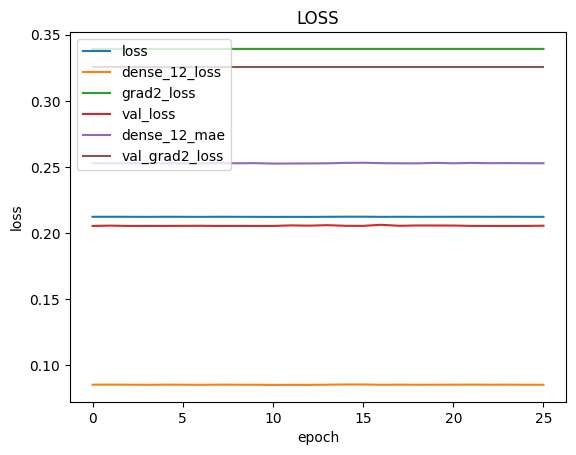

In [57]:
# summarize history for accuracy
plt.plot(history2.history['loss'])
# Dynamically get the loss and mae keys for the first dense layer
dense_loss_key = [key for key in history2.history.keys() if 'dense' in key and 'loss' in key][0]
dense_mae_key = [key for key in history2.history.keys() if 'dense' in key and 'mae' in key][0]

plt.plot(history2.history[dense_loss_key])
plt.plot(history2.history['grad2_loss'])
plt.plot(history2.history['val_loss'])
plt.plot(history2.history[dense_mae_key])
plt.plot(history2.history['val_grad2_loss'])
plt.title('LOSS')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['loss', dense_loss_key, 'grad2_loss','val_loss', dense_mae_key, 'val_grad2_loss'], loc='upper left')
#plt.show()
plt.savefig('plot1.pdf', bbox_inches='tight')

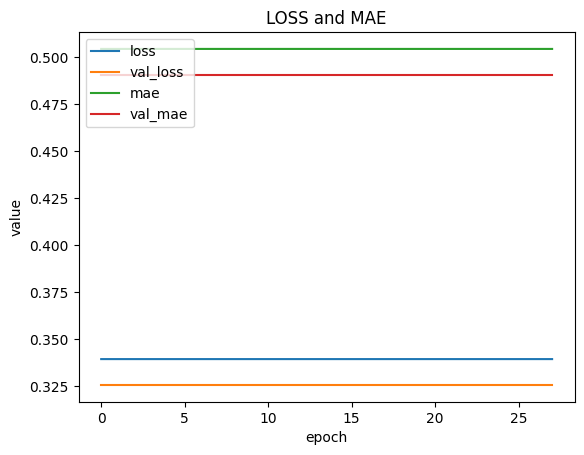

In [59]:
# summarize history for accuracy
plt.plot(history.history['loss'])
# Dynamically get the loss and mae keys
loss_keys = [key for key in history.history.keys() if 'loss' in key]
mae_keys = [key for key in history.history.keys() if 'mae' in key]

# Plot loss and mae if they exist
for key in loss_keys:
    if key != 'loss': # Avoid plotting 'loss' twice
        plt.plot(history.history[key])
for key in mae_keys:
    plt.plot(history.history[key])


plt.title('LOSS and MAE')
plt.ylabel('value')
plt.xlabel('epoch')

# Create legend based on existing keys
legend_labels = ['loss'] + [key for key in loss_keys if key != 'loss'] + mae_keys
plt.legend(legend_labels, loc='upper left')

#plt.show()
plt.savefig('plot1.pdf', bbox_inches='tight')